In [ ]:
!pip install hmmlearn scikit-learn matplotlib seaborn pyarrow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 2.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/PRISM'
PATHS = {
    'raw'      : f'{BASE_PATH}/raw',
    'features' : f'{BASE_PATH}/features',
    'splits'   : f'{BASE_PATH}/splits',
    'plots'    : f'{BASE_PATH}/plots',
    'models'   : f'{BASE_PATH}/models',
    'results'  : f'{BASE_PATH}/results'
}

for path in PATHS.values():
    os.makedirs(path, exist_ok=True)

print("Drive mounted and paths ready")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and paths ready


In [ ]:
hmm_input = pd.read_parquet(f"{PATHS['features']}/hmm_input.parquet")
hmm_train = pd.read_parquet(f"{PATHS['features']}/hmm_train.parquet")

print("--- HMM INPUT DATA ---")
print(f"Full dataset shape  : {hmm_input.shape}")
print(f"Training set shape  : {hmm_train.shape}")
print(f"Full date range     : {hmm_input.index[0].date()} to {hmm_input.index[-1].date()}")
print(f"Training date range : {hmm_train.index[0].date()} to {hmm_train.index[-1].date()}")
print(f"\nFeatures:")
print(hmm_train.head(10).round(5))
print(f"\nSummary statistics:")
print(hmm_train.describe().round(5))

--- HMM INPUT DATA ---
Full dataset shape  : (4007, 2)
Training set shape  : (2498, 2)
Full date range     : 2008-01-31 to 2023-12-29
Training date range : 2008-01-31 to 2017-12-29

Features:
            spy_return  spy_vol20
Date                             
2008-01-31     0.01807    0.01453
2008-02-01     0.01596    0.01511
2008-02-04    -0.01269    0.01437
2008-02-05    -0.02714    0.01549
2008-02-06    -0.00808    0.01521
2008-02-07     0.00659    0.01507
2008-02-08    -0.00644    0.01495
2008-02-11     0.00510    0.01500
2008-02-12     0.00923    0.01504
2008-02-13     0.01017    0.01452

Summary statistics:
       spy_return   spy_vol20
count  2498.00000  2498.00000
mean      0.00036     0.01031
std       0.01280     0.00780
min      -0.10364     0.00201
25%      -0.00384     0.00579
50%       0.00064     0.00828
75%       0.00550     0.01167
max       0.13558     0.05920


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(hmm_train.values)
X_full_scaled  = scaler.transform(hmm_input.values)

joblib.dump(scaler, f"{PATHS['models']}/hmm_scaler.pkl")

print(f"Training data scaled: {X_train_scaled.shape}")
print(f"Full data scaled    : {X_full_scaled.shape}")
print(f"Scaler mean         : {scaler.mean_.round(6)}")
print(f"Scaler std          : {scaler.scale_.round(6)}")
print(f"Scaler saved to Drive")

Training data scaled: (2498, 2)
Full data scaled    : (4007, 2)
Scaler mean         : [0.000357 0.010308]
Scaler std          : [0.012793 0.007802]
Scaler saved to Drive


In [ ]:
print("Training HMM across K = 2, 3, 4, 5...\n")

hmm_results = {}

for k in [2, 3, 4, 5]:
    best_model  = None
    best_score  = -np.inf

    # Run multiple times to avoid local optima
    for attempt in range(10):
        model = GaussianHMM(
            n_components=k,
            covariance_type='full',
            n_iter=1000,
            tol=1e-4,
            random_state=attempt
        )
        try:
            model.fit(X_train_scaled)
            score = model.score(X_train_scaled)
            if score > best_score:
                best_score = score
                best_model = model
        except:
            continue

    n = len(X_train_scaled)
    n_params = k * k + k * 2 + k * 4  # transitions + means + covariances (approx)
    aic = -2 * best_score * n + 2 * n_params
    bic = -2 * best_score * n + np.log(n) * n_params

    hmm_results[k] = {
        'model' : best_model,
        'score' : best_score * n,
        'aic'   : aic,
        'bic'   : bic
    }

    print(f"K={k} | Log-likelihood: {best_score * n:.2f} | AIC: {aic:.2f} | BIC: {bic:.2f}")

print("\nDone. Use AIC/BIC to select best K.")

Training HMM across K = 2, 3, 4, 5...

K=2 | Log-likelihood: -11032493.41 | AIC: 22065018.82 | BIC: 22065111.99
K=3 | Log-likelihood: -7919126.56 | AIC: 15838307.11 | BIC: 15838464.34
K=4 | Log-likelihood: -6394777.02 | AIC: 12789634.04 | BIC: 12789866.97
K=5 | Log-likelihood: -5104500.31 | AIC: 10209110.62 | BIC: 10209430.90

Done. Use AIC/BIC to select best K.


In [ ]:
print("--- MODEL SELECTION ---\n")

metrics = pd.DataFrame({
    'K'    : list(hmm_results.keys()),
    'LogL' : [hmm_results[k]['score'] for k in hmm_results],
    'AIC'  : [hmm_results[k]['aic']   for k in hmm_results],
    'BIC'  : [hmm_results[k]['bic']   for k in hmm_results]
})

print(metrics.round(2).to_string(index=False))

best_k_aic = metrics.loc[metrics['AIC'].idxmin(), 'K']
best_k_bic = metrics.loc[metrics['BIC'].idxmin(), 'K']

print(f"\nBest K by AIC : {best_k_aic}")
print(f"Best K by BIC : {best_k_bic}")

# Use BIC as final selector — penalizes complexity more, safer for small datasets
BEST_K = int(best_k_bic)
best_model = hmm_results[BEST_K]['model']

print(f"\nSelected K = {BEST_K} (BIC criterion)")
print(f"\nTransition Matrix:")
print(pd.DataFrame(best_model.transmat_.round(3),
      columns=[f'R{i}' for i in range(BEST_K)],
      index=[f'R{i}' for i in range(BEST_K)]))
print(f"\nRegime Means (spy_return, spy_vol):")
print(pd.DataFrame(scaler.inverse_transform(best_model.means_),
      columns=['SPY Return', 'SPY Vol 20d'],
      index=[f'Regime {i}' for i in range(BEST_K)]).round(5))

--- MODEL SELECTION ---

 K         LogL         AIC         BIC
 2 -11032493.41 22065018.82 22065111.99
 3  -7919126.56 15838307.11 15838464.34
 4  -6394777.02 12789634.04 12789866.97
 5  -5104500.31 10209110.62 10209430.90

Best K by AIC : 5
Best K by BIC : 5

Selected K = 5 (BIC criterion)

Transition Matrix:
       R0     R1     R2     R3     R4
R0  0.952  0.032  0.000  0.016  0.000
R1  0.036  0.934  0.000  0.000  0.030
R2  0.000  0.000  0.981  0.019  0.000
R3  0.028  0.000  0.007  0.965  0.000
R4  0.000  0.037  0.000  0.000  0.963

Regime Means (spy_return, spy_vol):
          SPY Return  SPY Vol 20d
Regime 0     0.00045      0.00957
Regime 1     0.00036      0.00640
Regime 2    -0.00191      0.03327
Regime 3     0.00063      0.01531
Regime 4     0.00069      0.00425


In [ ]:
# Identify which regime corresponds to bull, volatile, crisis
# based on mean SPY return and volatility

means_original = scaler.inverse_transform(best_model.means_)
means_df = pd.DataFrame(means_original,
           columns=['spy_return', 'spy_vol'],
           index=range(BEST_K))

print("--- REGIME CHARACTERIZATION ---\n")
print(means_df.round(6))

# Label by volatility: lowest vol = bull, highest vol = crisis, middle = volatile
vol_order = means_df['spy_vol'].argsort().values

if BEST_K == 2:
    regime_names = {vol_order[0]: 'Bull', vol_order[1]: 'Crisis'}
elif BEST_K == 3:
    regime_names = {vol_order[0]: 'Bull', vol_order[1]: 'Volatile', vol_order[2]: 'Crisis'}
elif BEST_K == 4:
    regime_names = {vol_order[0]: 'Bull', vol_order[1]: 'Mild Volatile',
                    vol_order[2]: 'High Volatile', vol_order[3]: 'Crisis'}
elif BEST_K == 5:
    regime_names = {vol_order[0]: 'Bull', vol_order[1]: 'Mild Volatile',
                    vol_order[2]: 'Moderate', vol_order[3]: 'High Volatile',
                    vol_order[4]: 'Crisis'}

print(f"\nRegime Labels (K={BEST_K}):")
for idx, name in regime_names.items():
    print(f"  Regime {idx} -> {name} | return={means_df.loc[idx,'spy_return']:.5f} | vol={means_df.loc[idx,'spy_vol']:.5f}")

--- REGIME CHARACTERIZATION ---

   spy_return   spy_vol
0    0.000454  0.009569
1    0.000362  0.006403
2   -0.001905  0.033269
3    0.000632  0.015309
4    0.000693  0.004246

Regime Labels (K=5):
  Regime 4 -> Bull | return=0.00069 | vol=0.00425
  Regime 1 -> Mild Volatile | return=0.00036 | vol=0.00640
  Regime 0 -> Moderate | return=0.00045 | vol=0.00957
  Regime 3 -> High Volatile | return=0.00063 | vol=0.01531
  Regime 2 -> Crisis | return=-0.00191 | vol=0.03327


In [ ]:
print("Extracting regime probabilities for full dataset...\n")

# Probabilistic output — shape (n_days, K)
regime_probs = best_model.predict_proba(X_full_scaled)
regime_labels = best_model.predict(X_full_scaled)

# Build DataFrames
prob_cols = [f'prob_{regime_names[i].lower().replace(" ","_")}' for i in range(BEST_K)]

regime_probs_df = pd.DataFrame(
    regime_probs,
    index=hmm_input.index,
    columns=prob_cols
)

regime_labels_df = pd.Series(
    regime_labels,
    index=hmm_input.index,
    name='regime_label'
)

print(f"Regime probability shape : {regime_probs_df.shape}")
print(f"\nFirst 10 rows:")
print(regime_probs_df.head(10).round(4))
print(f"\nRegime distribution (hard labels):")
print(regime_labels_df.value_counts().rename(regime_names))

# Save
regime_probs_df.to_parquet(f"{PATHS['results']}/regime_probs.parquet")
regime_labels_df.to_frame().to_parquet(f"{PATHS['results']}/regime_labels.parquet")
joblib.dump(best_model, f"{PATHS['models']}/hmm_best.pkl")

print(f"\nAll saved to Drive")

Extracting regime probabilities for full dataset...

Regime probability shape : (4007, 5)

First 10 rows:
            prob_moderate  prob_mild_volatile  prob_crisis  \
Date                                                         
2008-01-31            0.0                 0.0          0.0   
2008-02-01            0.0                 0.0          0.0   
2008-02-04            0.0                 0.0          0.0   
2008-02-05            0.0                 0.0          0.0   
2008-02-06            0.0                 0.0          0.0   
2008-02-07            0.0                 0.0          0.0   
2008-02-08            0.0                 0.0          0.0   
2008-02-11            0.0                 0.0          0.0   
2008-02-12            0.0                 0.0          0.0   
2008-02-13            0.0                 0.0          0.0   

            prob_high_volatile  prob_bull  
Date                                       
2008-01-31                 1.0        0.0  
2008-02-01       

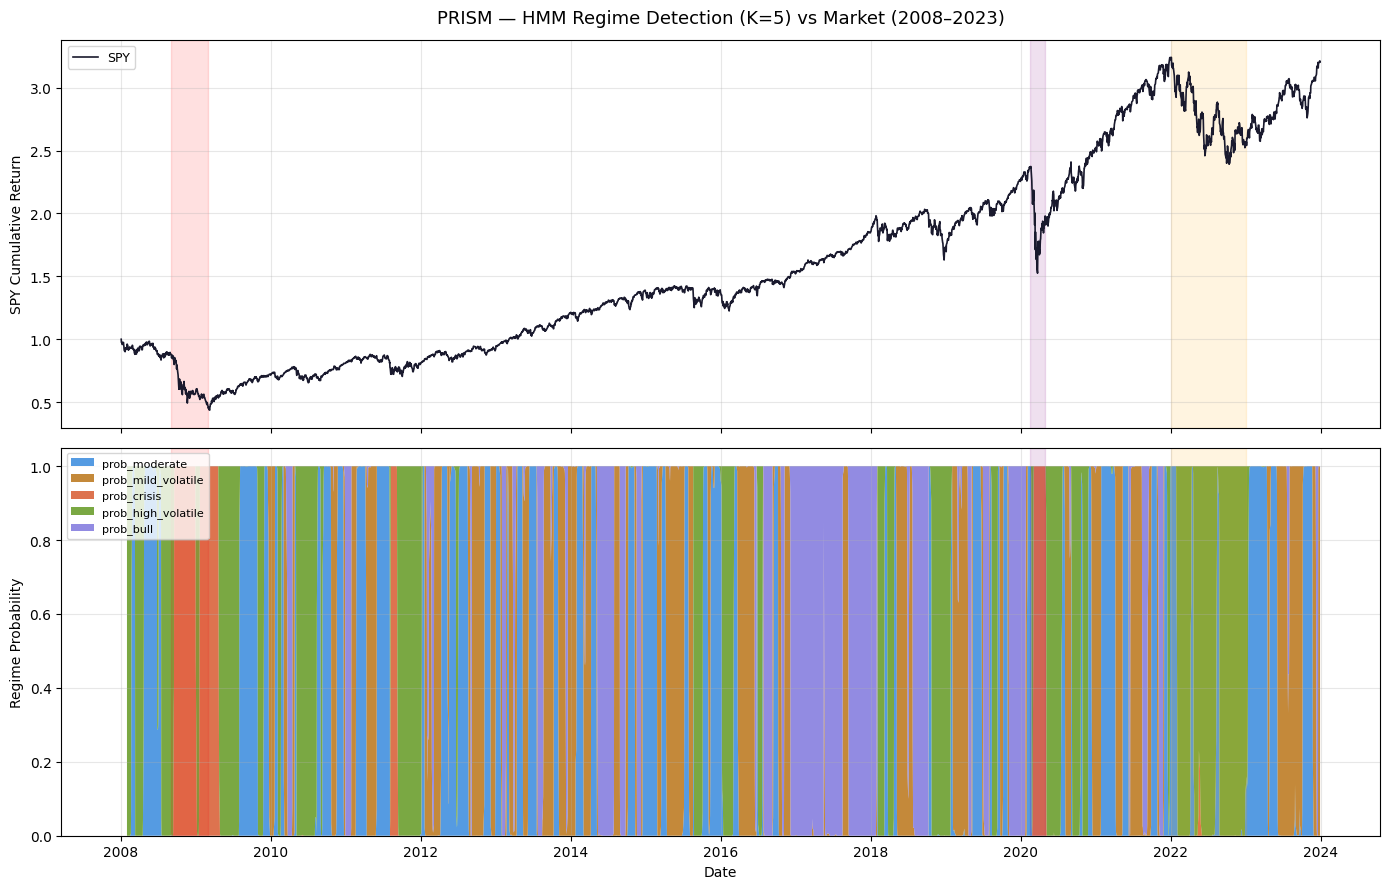

Plot 1 saved


In [ ]:
spy_close = pd.read_parquet(f"{BASE_PATH}/raw/close.parquet")['SPY']
spy_cumret = (1 + np.log(spy_close / spy_close.shift(1))).cumprod().dropna()

colors_regime = ['#378ADD', '#BA7517', '#D85A30', '#639922', '#7F77DD']
crisis_color  = colors_regime[BEST_K - 2] if BEST_K <= 3 else colors_regime[2]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Top: SPY cumulative return
axes[0].plot(spy_cumret.index, spy_cumret.values,
             color='#1a1a2e', linewidth=1.2, label='SPY')
axes[0].set_ylabel('SPY Cumulative Return', fontsize=10)
axes[0].set_title(f'PRISM — HMM Regime Detection (K={BEST_K}) vs Market (2008–2023)',
                  fontsize=13, fontweight='500', pad=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Bottom: stacked regime probabilities
axes[1].stackplot(
    regime_probs_df.index,
    [regime_probs_df[col] for col in prob_cols],
    labels=prob_cols,
    colors=colors_regime[:BEST_K],
    alpha=0.85
)
axes[1].set_ylabel('Regime Probability', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].legend(loc='upper left', fontsize=8)
axes[1].grid(True, alpha=0.3)

# Annotate known events on both panels
events = {
    'GFC 2008'      : ('2008-09-01', '2009-03-01', 'red'),
    'COVID'         : ('2020-02-15', '2020-04-30', 'purple'),
    'Rate Shock'    : ('2022-01-01', '2022-12-31', 'orange'),
}

for label, (start, end, color) in events.items():
    for ax in axes:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.12, color=color, label=label)

plt.tight_layout()
plt.savefig(f"{PATHS['plots']}/06_regime_probabilities.png", dpi=150)
plt.show()
print("Plot 1 saved")

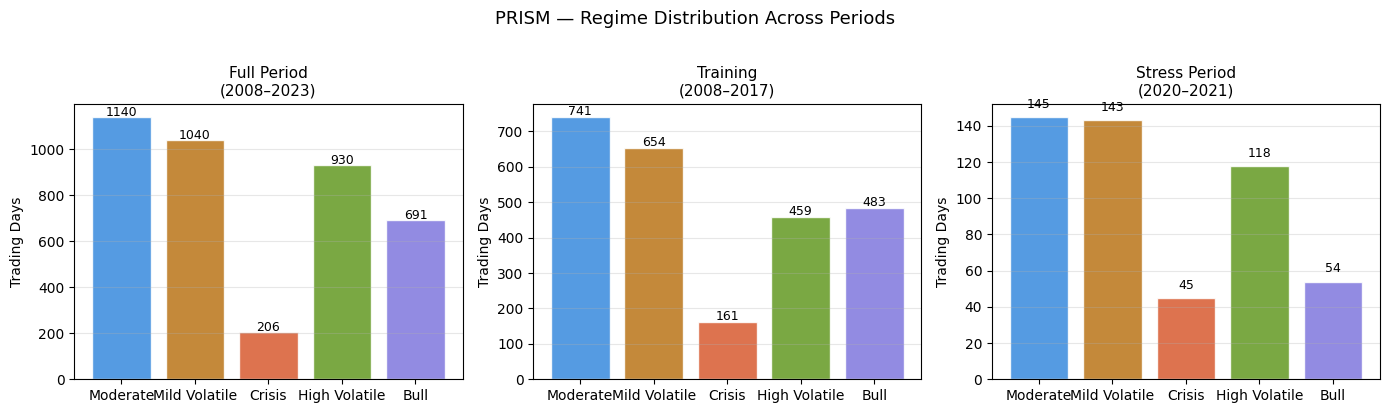

Plot 2 saved


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

periods = {
    'Full Period\n(2008–2023)' : regime_labels_df,
    'Training\n(2008–2017)'   : regime_labels_df['2008':'2017'],
    'Stress Period\n(2020–2021)': regime_labels_df['2020':'2021']
}

for ax, (title, data) in zip(axes, periods.items()):
    counts = data.value_counts().sort_index()
    counts.index = [regime_names.get(i, f'R{i}') for i in counts.index]
    bars = ax.bar(counts.index, counts.values,
                  color=colors_regime[:len(counts)], alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='500')
    ax.set_ylabel('Trading Days')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', fontsize=9)

plt.suptitle('PRISM — Regime Distribution Across Periods',
             fontsize=13, fontweight='500', y=1.02)
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}/07_regime_distribution.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved")

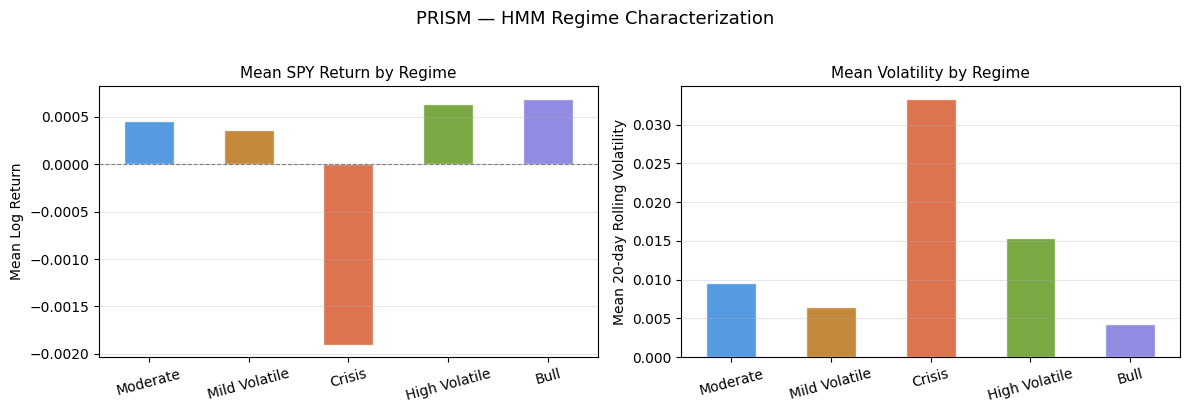

Plot 3 saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

regime_char = pd.DataFrame(
    scaler.inverse_transform(best_model.means_),
    columns=['SPY Return', 'SPY Volatility'],
    index=[regime_names[i] for i in range(BEST_K)]
)

regime_char['SPY Return'].plot(kind='bar', ax=axes[0],
    color=colors_regime[:BEST_K], alpha=0.85, edgecolor='white')
axes[0].set_title('Mean SPY Return by Regime', fontsize=11, fontweight='500')
axes[0].set_ylabel('Mean Log Return')
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, alpha=0.3, axis='y')

regime_char['SPY Volatility'].plot(kind='bar', ax=axes[1],
    color=colors_regime[:BEST_K], alpha=0.85, edgecolor='white')
axes[1].set_title('Mean Volatility by Regime', fontsize=11, fontweight='500')
axes[1].set_ylabel('Mean 20-day Rolling Volatility')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('PRISM — HMM Regime Characterization',
             fontsize=13, fontweight='500', y=1.02)
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}/08_regime_characterization.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved")

In [ ]:
print("Building rolling HMM retraining pipeline...\n")
print("This retrains HMM monthly on a 5-year rolling window.")
print("Slower to run — this is the production-grade regime estimator.\n")

WINDOW_YEARS = 5
RETRAIN_FREQ  = 'MS'  # monthly start

test_start = pd.Timestamp('2018-01-01')
retrain_dates = pd.date_range(start=test_start,
                              end=hmm_input.index[-1],
                              freq=RETRAIN_FREQ)

rolling_probs = []
rolling_index = []

for i, retrain_date in enumerate(retrain_dates):
    window_start = retrain_date - pd.DateOffset(years=WINDOW_YEARS)
    window_end   = retrain_date

    X_window = scaler.fit_transform(
        hmm_input[window_start:window_end].values
    )

    if len(X_window) < 100:
        continue

    roll_model = GaussianHMM(
        n_components=BEST_K,
        covariance_type='full',
        n_iter=500,
        random_state=42
    )
    roll_model.fit(X_window)

    # Get dates for this month
    if i < len(retrain_dates) - 1:
        month_dates = hmm_input[retrain_date:retrain_dates[i+1]].index
    else:
        month_dates = hmm_input[retrain_date:].index

    if len(month_dates) == 0:
        continue

    X_month = scaler.transform(hmm_input.loc[month_dates].values)
    month_probs = roll_model.predict_proba(X_month)

    rolling_probs.append(month_probs)
    rolling_index.extend(month_dates)

    if i % 12 == 0:
        print(f"  Processed through {retrain_date.date()}")

rolling_probs_arr = np.vstack(rolling_probs)
rolling_probs_df  = pd.DataFrame(
    rolling_probs_arr,
    index=rolling_index,
    columns=prob_cols
)

rolling_probs_df.to_parquet(f"{PATHS['results']}/regime_probs_rolling.parquet")
print(f"\nRolling regime probs shape : {rolling_probs_df.shape}")
print(f"Date range                 : {rolling_probs_df.index[0].date()} to {rolling_probs_df.index[-1].date()}")
print(f"Saved to Drive")

Building rolling HMM retraining pipeline...

This retrains HMM monthly on a 5-year rolling window.
Slower to run — this is the production-grade regime estimator.

  Processed through 2018-01-01
  Processed through 2019-01-01
  Processed through 2020-01-01
  Processed through 2021-01-01
  Processed through 2022-01-01


  Processed through 2023-01-01

Rolling regime probs shape : (1557, 5)
Date range                 : 2018-01-02 to 2023-12-29
Saved to Drive


In [ ]:
print("=== HMM VALIDATION ===\n")
print("Checking if HMM correctly identifies known market stress periods:\n")

crisis_col = [col for col in prob_cols if 'crisis' in col][0]

validation_periods = {
    'GFC Peak (Oct 2008)'        : '2008-10',
    'GFC Recovery (Jun 2009)'    : '2009-06',
    'Bull Market (Jan 2017)'     : '2017-01',
    'COVID Crash (Mar 2020)'     : '2020-03',
    'COVID Recovery (Aug 2020)'  : '2020-08',
    'Rate Shock (Jun 2022)'      : '2022-06',
    'Calm Period (Jan 2019)'     : '2019-01',
}

print(f"{'Period':<35} {'Crisis Prob':>12} {'Assessment'}")
print("-" * 65)

for period, date in validation_periods.items():
    try:
        avg_crisis_prob = regime_probs_df[crisis_col][date].mean()
        assessment = "HIGH STRESS" if avg_crisis_prob > 0.5 else \
                     "ELEVATED"   if avg_crisis_prob > 0.25 else "CALM"
        print(f"{period:<35} {avg_crisis_prob:>11.3f}  {assessment}")
    except:
        print(f"{period:<35} {'N/A':>12}")

print("\nExpected: GFC and COVID months should show HIGH STRESS.")
print("If calm periods show HIGH STRESS, the HMM needs retuning.")

=== HMM VALIDATION ===

Checking if HMM correctly identifies known market stress periods:

Period                               Crisis Prob Assessment
-----------------------------------------------------------------
GFC Peak (Oct 2008)                       1.000  HIGH STRESS
GFC Recovery (Jun 2009)                   0.000  CALM
Bull Market (Jan 2017)                    0.000  CALM
COVID Crash (Mar 2020)                    0.963  HIGH STRESS
COVID Recovery (Aug 2020)                 0.000  CALM
Rate Shock (Jun 2022)                     0.000  CALM
Calm Period (Jan 2019)                    0.000  CALM

Expected: GFC and COVID months should show HIGH STRESS.
If calm periods show HIGH STRESS, the HMM needs retuning.


In [ ]:
print("=" * 55)
print("   PRISM — HMM COMPLETE")
print("=" * 55)
print(f"\nBest K selected    : {BEST_K} regimes")
print(f"Regime labels      : {list(regime_names.values())}")
print(f"\nFiles saved:")
print(f"  models/hmm_best.pkl")
print(f"  models/hmm_scaler.pkl")
print(f"  results/regime_probs.parquet")
print(f"  results/regime_labels.parquet")
print(f"  results/regime_probs_rolling.parquet")
print(f"  plots/06_regime_probabilities.png")
print(f"  plots/07_regime_distribution.png")
print(f"  plots/08_regime_characterization.png")
print(f"\nValidation check:")
print(f"  GFC and COVID periods should show elevated crisis probability.")
print(f"  If validation passed, HMM is ready.")
print("=" * 55)
print("\nHMM complete. Ready for LSTM encoder.")

   PRISM — HMM COMPLETE

Best K selected    : 5 regimes
Regime labels      : ['Bull', 'Mild Volatile', 'Moderate', 'High Volatile', 'Crisis']

Files saved:
  models/hmm_best.pkl
  models/hmm_scaler.pkl
  results/regime_probs.parquet
  results/regime_labels.parquet
  results/regime_probs_rolling.parquet
  plots/06_regime_probabilities.png
  plots/07_regime_distribution.png
  plots/08_regime_characterization.png

Validation check:
  GFC and COVID periods should show elevated crisis probability.
  If validation passed, HMM is ready.

HMM complete. Ready for LSTM encoder.


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import joblib

# Load saved model and scaler
hmm_model = joblib.load('/content/drive/MyDrive/PRISM/models/hmm_best.pkl')
scaler    = joblib.load('/content/drive/MyDrive/PRISM/models/hmm_scaler.pkl')

# Pull recent SPY data
spy = yf.download('SPY', period='3mo', auto_adjust=True)
spy_returns = np.log(spy['Close'] / spy['Close'].shift(1))
spy_vol20   = spy_returns.rolling(20).std()

# Build today's input
today_input = pd.DataFrame({
    'spy_return' : spy_returns,
    'spy_vol20'  : spy_vol20
}).dropna()

# Scale and predict
today_scaled = scaler.transform(today_input.values)
regime_probs  = hmm_model.predict_proba(today_scaled)

# Get today's regime
latest_probs = regime_probs[-1]
regime_names = ['Bull', 'Mild Volatile', 'Moderate', 'High Volatile', 'Crisis']

print("=== CURRENT MARKET REGIME (Today) ===\n")
for name, prob in zip(regime_names, latest_probs):
    bar = '█' * int(prob * 40)
    print(f"{name:<15} {prob:.3f}  {bar}")

print(f"\nDominant regime: {regime_names[np.argmax(latest_probs)]}")

[*********************100%***********************]  1 of 1 completed


ValueError: If using all scalar values, you must pass an index

Input shape    : (43, 2)
Date range     : 2026-03-17 to 2026-05-15

Last 5 rows:
            spy_return  spy_vol20
Date                             
2026-05-11    0.002275   0.006431
2026-05-12   -0.001516   0.006215
2026-05-13    0.005579   0.006143
2026-05-14    0.007863   0.006239
2026-05-15   -0.012102   0.006756

=== CURRENT MARKET REGIME (2026-05-15) ===

Bull            0.003  
Mild Volatile   0.997  ███████████████████████████████████████
Moderate        0.000  
High Volatile   0.000  
Crisis          0.000  

Dominant regime : Mild Volatile
Crisis prob     : 0.000


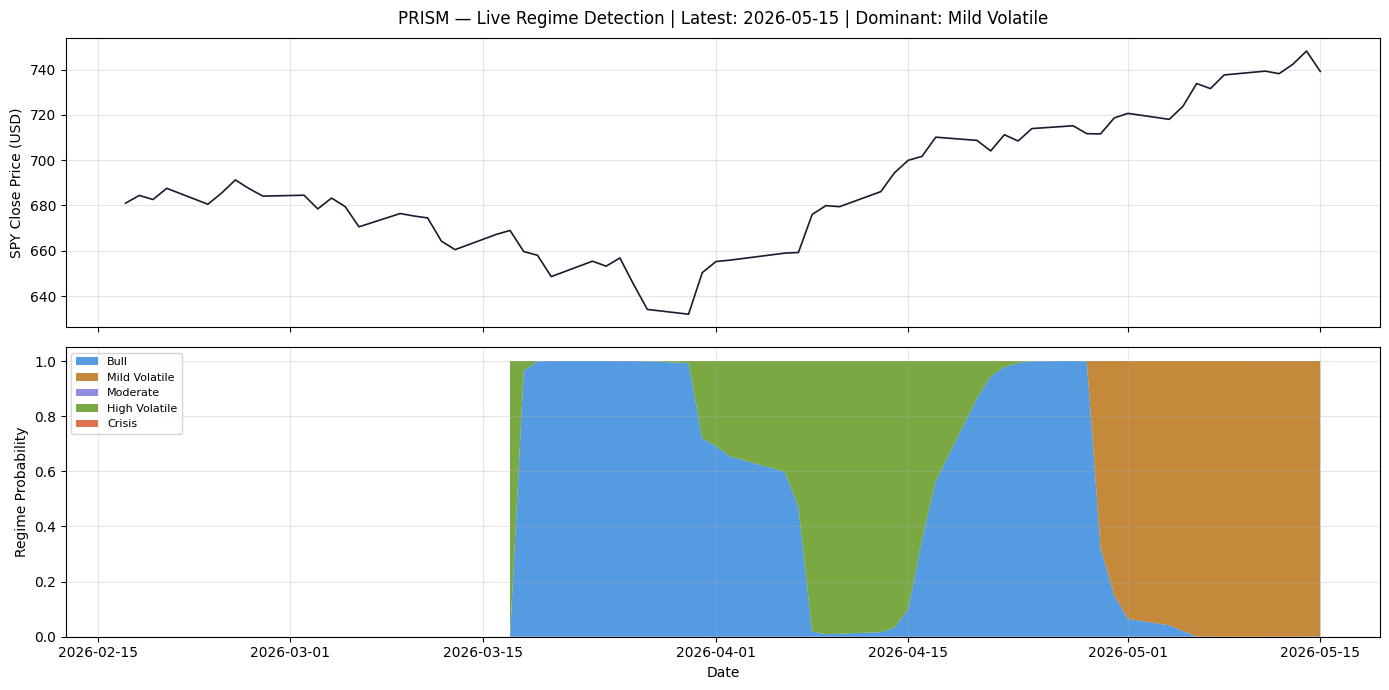


Live regime plot saved to Drive


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import joblib

# Load saved model and scaler
hmm_model = joblib.load('/content/drive/MyDrive/PRISM/models/hmm_best.pkl')
scaler    = joblib.load('/content/drive/MyDrive/PRISM/models/hmm_scaler.pkl')

# Pull recent SPY data
spy_raw = yf.download('SPY', period='3mo', auto_adjust=True, progress=False)

# Flatten MultiIndex columns if present
if isinstance(spy_raw.columns, pd.MultiIndex):
    spy_raw.columns = spy_raw.columns.get_level_values(0)

# Compute features
spy_returns = np.log(spy_raw['Close'] / spy_raw['Close'].shift(1)).dropna()
spy_vol20   = spy_returns.rolling(20).std().dropna()

# Align and build input
today_input = pd.concat([spy_returns, spy_vol20], axis=1).dropna()
today_input.columns = ['spy_return', 'spy_vol20']

print(f"Input shape    : {today_input.shape}")
print(f"Date range     : {today_input.index[0].date()} to {today_input.index[-1].date()}")
print(f"\nLast 5 rows:")
print(today_input.tail().round(6))

# Scale and predict
today_scaled  = scaler.transform(today_input.values)
regime_probs  = hmm_model.predict_proba(today_scaled)

# Regime names — must match order from HMM training
regime_names = ['Bull', 'Mild Volatile', 'Moderate', 'High Volatile', 'Crisis']

# Latest day regime probabilities
latest_probs = regime_probs[-1]
latest_date  = today_input.index[-1].date()

print(f"\n=== CURRENT MARKET REGIME ({latest_date}) ===\n")
for name, prob in zip(regime_names, latest_probs):
    bar = '█' * int(prob * 40)
    print(f"{name:<15} {prob:.3f}  {bar}")

dominant = regime_names[np.argmax(latest_probs)]
print(f"\nDominant regime : {dominant}")
print(f"Crisis prob     : {latest_probs[4]:.3f}")

# Plot last 3 months of regime evolution
import matplotlib.pyplot as plt

colors_regime = ['#378ADD', '#BA7517', '#7F77DD', '#639922', '#D85A30']

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top: SPY price
axes[0].plot(spy_raw.index, spy_raw['Close'],
             color='#1a1a2e', linewidth=1.2)
axes[0].set_ylabel('SPY Close Price (USD)', fontsize=10)
axes[0].set_title(f'PRISM — Live Regime Detection | Latest: {latest_date} | Dominant: {dominant}',
                  fontsize=12, fontweight='500', pad=10)
axes[0].grid(True, alpha=0.3)

# Bottom: stacked regime probabilities
aligned_probs = pd.DataFrame(
    regime_probs,
    index=today_input.index,
    columns=regime_names
)

axes[1].stackplot(
    aligned_probs.index,
    [aligned_probs[r] for r in regime_names],
    labels=regime_names,
    colors=colors_regime,
    alpha=0.85
)
axes[1].set_ylabel('Regime Probability', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].legend(loc='upper left', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PRISM/plots/09_live_regime_2026.png', dpi=150)
plt.show()

print("\nLive regime plot saved to Drive")